## Визуализация графов с путями

In [1]:
import sys
sys.path.append('..')
from experiments.visualization import *
from graph.graph import Graph
from graph.coxian import CoxianDistribution
from graph.factory import GraphFactory
from algorithms.dijkstra import Dijkstra
from algorithms.adaptive_dijkstra import AdaptiveDijkstra
from algorithms.expected_dijkstra import ExpectedDijkstra

In [2]:
# Создаём граф с неоднородными рёбрами
graph = GraphFactory.create_random(
    n=8, edge_prob=0.4,
    mu_func=lambda u, v: [0.5 + (u + v) % 5 * 0.4],
    p_func=lambda u, v: [],
    seed=42
)
graph.update_all_weights(0)
print_edge_weights(graph)

Текущие веса рёбер:
(0 -> 1): 0.103
(0 -> 5): 0.436
(0 -> 6): 0.051
(0 -> 7): 0.303
(1 -> 4): 0.984
(1 -> 7): 0.186
(2 -> 0): 1.357
(2 -> 1): 0.260
(2 -> 3): 0.660
(2 -> 6): 0.460
(3 -> 0): 0.089
(3 -> 1): 0.772
(3 -> 2): 0.155
(3 -> 6): 2.064
(4 -> 1): 2.959
(4 -> 3): 0.170
(4 -> 5): 0.003
(5 -> 1): 1.878
(5 -> 2): 0.944
(5 -> 6): 1.451
(6 -> 0): 1.639
(6 -> 2): 0.045
(6 -> 4): 0.888
(7 -> 0): 0.095


In [3]:
# Запускаем все три алгоритма
source, target = 0, 7
paths = {}

for name, alg_class in [('Dijkstra', Dijkstra),
                         ('Adaptive', AdaptiveDijkstra),
                         ('Expected', ExpectedDijkstra)]:
    g = graph.copy()
    time_taken, path = alg_class().find_path(g, source, target)
    if path:
        paths[name] = path
        print(f"{name}: путь {path}, время {time_taken:.3f}")
    else:
        print(f"{name}: путь не найден")

Dijkstra: путь [0, 1, 7], время 2.378
Adaptive: путь [0, 1, 7], время 1.707
Expected: путь [0, 7], время 0.293


C:\Users\P\scoop\apps\anaconda3\current\App\Lib\site-packages\networkx\drawing\nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


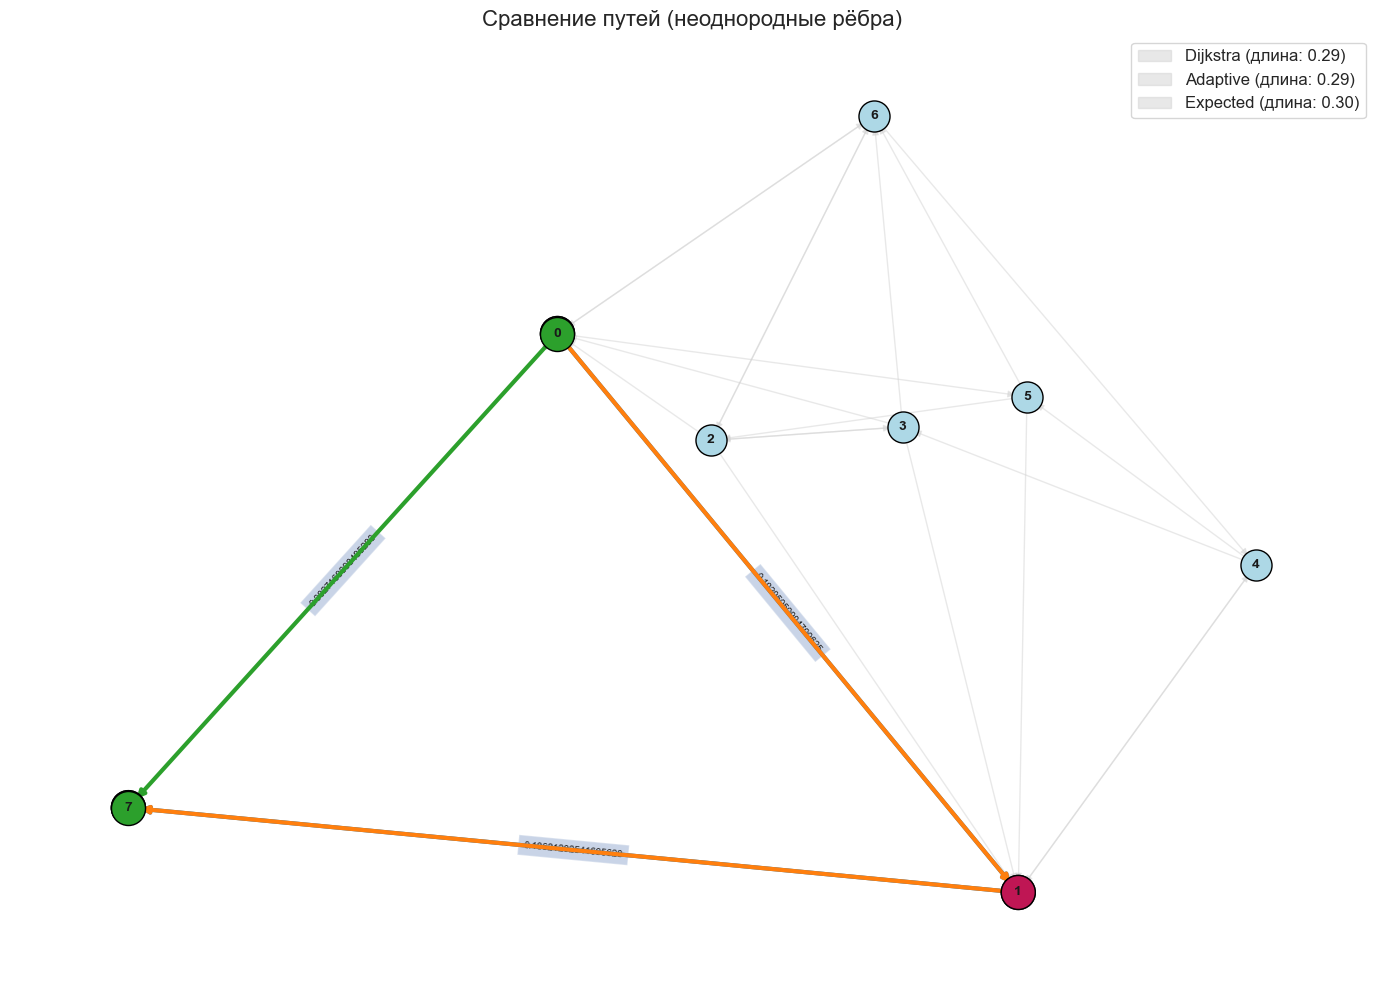

In [4]:
# Визуализация с подписями весов только на рёбрах путей
visualize_graph_with_paths(
    graph, paths,
    title="Сравнение путей (неоднородные рёбра)",
    edge_labels_on_paths_only=True,
    figsize=(14, 10),
    save_path="paths_example.png"
)

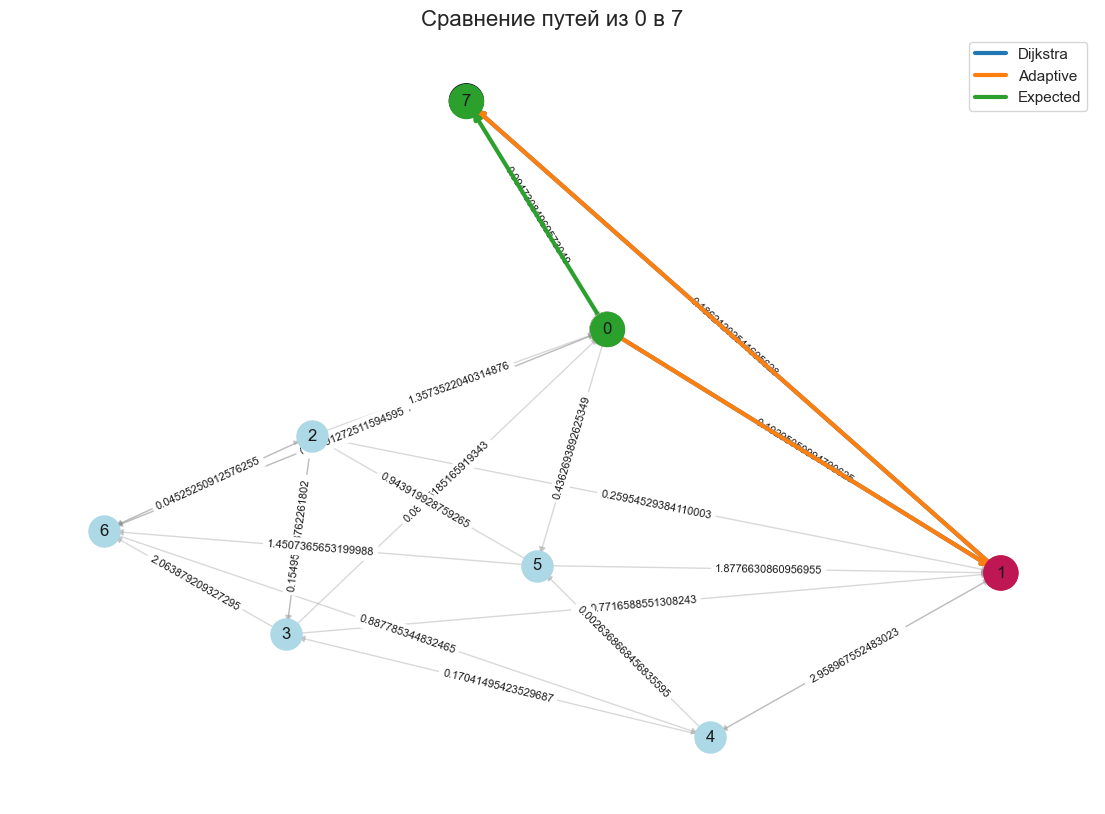

Сводка сохранена в paths_summary.txt


In [5]:
# Сравнение путей с полными подписями весов
plot_path_comparison(graph, source, target, paths, save_path="path_comparison.png")

# Текстовая сводка
save_paths_summary(graph, paths, "paths_summary.txt")